In [2]:
import subprocess
import shlex

import graph_tool.all as gt
from graph_tool.topology import extract_largest_component
import numpy as np
import pandas as pd
import igraph as ig
import leidenalg

from utils.WeightedCheckUtil import *
from utils.HubConnectivityScore import calculate_hcs_pair
from utils.SmallWorld import *

import csv

import glob
import os
import json

from scipy.stats import linregress
import matplotlib.pyplot as plt

In [3]:
analysis_folder = "./analysis_data/"

In [4]:
def runAlgorithm(**kwargs):
    
    # Default arguments of the method:
    default_args = {'type': 'gen', 'graph': "flower 1000 1 2", 'method': 'sketch', 'alpha': '1', 'least_coverage': '1',
           'sketch_k': '128', 'multipass': '10000', 'rad_min': '1', 'rad_max': '30', 'random_seed': '114514'}
    
    options = ""
    
    for key in kwargs:
        default_args[key] = kwargs[key]
        
    if default_args['type'] == 'gen':
        a = default_args['graph']
        default_args['graph'] = f'"{a}"'
            
    for key in default_args:
        options += f" -{key}={default_args[key]}"
        
    subprocess.run(shlex.split(f"./bin/box_cover {options}"), cwd='./graph_sketch_fractality')

In [5]:
def saveTSV(filePath, graph):
    with open(filePath, "w", newline="") as tsvfile:
        writer = csv.writer(tsvfile, delimiter="\t")

        for e in graph.edges():
            source = e.source()
            target = e.target()
            writer.writerow([source, target])

In [6]:
def get_latest_output_json():
    list_of_files = glob.glob('./graph_sketch_fractality/jlog/*')
    latest_file = max(list_of_files, key=os.path.getctime)

    f = open(latest_file, "r").read()
    json_file = json.loads(f)

    return json_file

In [7]:
def prepare_folder(graph_name):
    safe_graph_name = graph_name.replace('/', '__')
    path = f"{analysis_folder}{safe_graph_name}"
    if not os.path.exists(path):
        os.makedirs(path)
    return path

In [8]:
def save_json(path, json_file):
    with open(path, "w") as outfile:
        json.dump(json_file, outfile)

In [9]:
def set_plotting_style():
    plt.rcParams['lines.linewidth'] = 2
    plt.rcParams['lines.markeredgewidth'] = 2
    plt.rcParams['lines.markersize'] = 10
    plt.rcParams['axes.linewidth'] = 2
    plt.rcParams['font.size'] = 20
    plt.rcParams['legend.fontsize'] = 20 * 0.6
    plt.rcParams['figure.subplot.left'] = 0.25
    plt.rcParams['figure.subplot.right'] = 0.95
    plt.rcParams['figure.subplot.bottom'] = 0.2
    plt.rcParams['figure.subplot.top'] = 0.9
    plt.rcParams['xtick.bottom'] = True
    plt.rcParams['xtick.top'] = True
    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['xtick.minor.size'] = 4
    plt.rcParams['xtick.minor.width'] = 2
    plt.rcParams['xtick.major.size'] = 8
    plt.rcParams['xtick.major.width'] = 2
    plt.rcParams['ytick.left'] = True
    plt.rcParams['ytick.right'] = True
    plt.rcParams['ytick.direction'] = 'in'
    plt.rcParams['ytick.minor.size'] = 4
    plt.rcParams['ytick.minor.width'] = 2
    plt.rcParams['ytick.major.size'] = 8
    plt.rcParams['ytick.major.width'] = 2

In [10]:
def is_weight_type_supported(type):
    supported_types = ['int16_t', 'int32_t', 'int64_t', 'float', 'double', 'long double']
    return type in supported_types

In [11]:
def get_mst(graph, edge_property = np.nan):
    if(edge_property is np.nan):
        weight_key = "weight"
    else:
        weight_key = edge_property
    
    if weight_key in graph.edge_properties and is_weight_type_supported(graph.ep[weight_key].value_type()):
        graph.ep[weight_key].a *= -1
    else:
        # TODO: add logic of throw error
        print("no weight")
        return False
    mst_tree = gt.min_spanning_tree(graph, graph.ep[weight_key])

    return gt.GraphView(graph, efilt=mst_tree)

In [12]:
def wmse(y_fit, x, y, w):
    return sum(w * (y_fit - y) ** 2) / sum(w) / len(y_fit)

In [13]:
def calculate_n_plot_power_law(radius, size, folder_path, fig_suffix = ""):
    box_sizes = [rb for rb in radius]

    x = np.array(box_sizes)
    y = np.array(size)
    x_log = np.log10(box_sizes)
    y_log = np.log10(size)

    fit_pl = linregress(x_log, y_log)
    fit_exp = linregress(x, y_log)

    y_log_pl = fit_pl.slope * x_log + fit_pl.intercept
    y_log_exp = fit_exp.slope * x + fit_exp.intercept

    x_plot = np.linspace(x.min(), x.max(), 100)
    x_log_plot = np.log10(x_plot)
    y_log_exp_plot = fit_exp.slope * x_plot + fit_exp.intercept

    set_plotting_style()

    fig = plt.figure(figsize=(6, 6))
    plt.scatter(x_log, y_log)
    plt.plot(x_log, y_log_pl,
             label='$N_\mathrm{B}\propto l_\mathrm{B}^{%.2f}$' % fit_pl.slope)
    plt.plot(x_log_plot, y_log_exp_plot,
             label='$N_\mathrm{B}\propto e^{%.2f l_\mathrm{B}}$' % fit_exp.slope)
    plt.xlabel('$\log(l_\mathrm{B})$')
    plt.ylabel('$\log(N_\mathrm{B})$')
    plt.legend()
    plt.savefig(f"{folder_path}/power_law_fit{fig_suffix}.svg")

    wmse_pl = wmse(y_fit=y_log_pl, x=x_log, y=y_log, w=size)

    wmse_exp = wmse(y_fit=y_log_exp, x=x_log, y=y_log, w=size)

    pl_ex_ratio = wmse_pl / wmse_exp

    return fit_pl.slope, fit_exp.slope, wmse_pl, wmse_exp, pl_ex_ratio

In [14]:
def run_box_covering(graph, folder_path, is_mst):
    suffix = "mst" if is_mst else "graph"

    tsv_path = f"{folder_path}/{suffix}.tsv"
    saveTSV(tsv_path, graph)

    runAlgorithm(type="tsv", graph=f".{tsv_path}")

    json = get_latest_output_json()
    save_json(f"{folder_path}/box_{suffix}_result.json", json)

    radius = json['radius']
    size = json['size']

    return calculate_n_plot_power_law(radius, size, folder_path, f'_{suffix}')

# def run_box_covering(graph, folder_path, weight_key = np.nan, ):
#     mst = get_mst(graph, weight_key)
#     mst_results = np.nan, np.nan, np.nan
#     if(mst):
#         tsv_path = f"{folder_path}/mst.tsv"
#         saveTSV(tsv_path, mst)

#         runAlgorithm(type="tsv", graph=f".{tsv_path}")

#         json_mst = get_latest_output_json()
#         save_json(f"{folder_path}/box_mst_result.json", json_mst)

#         radius_mst = json_mst['radius']
#         size_mst = json_mst['size']

#     graph_tsv_path = f"{folder_path}/graph.tsv"
#     saveTSV(graph_tsv_path, graph)
#     runAlgorithm(type="tsv", graph=f".{graph_tsv_path}")

#     json_graph = get_latest_output_json()
#     save_json(f"{folder_path}/box_graph_result.json", json_graph)


#     radius_graph = json_graph['radius']
#     size_graph = json_graph['size']

#     if(mst):
#         mst_results =  calculate_n_plot_power_law(radius_mst, size_mst, folder_path, fig_suffix="_mst")
#     graph_results = calculate_n_plot_power_law(radius_graph, size_graph, folder_path, fig_suffix="_graph")
#     return (mst_results, graph_results)

In [15]:
def calculate_assortativity(graph, degree_property):
    assortativity_undirected, variance_undirected = gt.assortativity(graph, deg=degree_property)
    return assortativity_undirected, variance_undirected

In [16]:
def create_series(
        graph_name,
        is_mst,
        modularity_score,
        small_world_result,
        hcs_std,
        hcs_mean,
        assortativity_undirected,
        variance_undirected,
        fit_pl,
        fit_exp,
        wmse_pl,
        wmse_exp,
        pl_ex_ratio
):
    return pd.Series({
        'name': graph_name,
        'is_mst': is_mst,
        'modularity': modularity_score,
        'small_world': small_world_result.to_dict() if small_world_result is not np.nan else np.nan,
        'hcs_std': hcs_std,
        'hcs_mean': hcs_mean,
        'assortativity': assortativity_undirected,
        'variance': variance_undirected,
        'fit_pl': fit_pl,
        'fit_exp': fit_exp,
        'wmse_pl': wmse_pl,
        'wmse_exp': wmse_exp,
        'pl_ex_ratio': pl_ex_ratio
    })

def create_nan_series(graph_name, is_mst):
    return create_series(
        graph_name=graph_name,
        is_mst=is_mst,
        modularity_score=np.nan,
        small_world_result=np.nan,
        hcs_std=np.nan,
        hcs_mean=np.nan,
        assortativity_undirected=np.nan,
        variance_undirected=np.nan,
        fit_pl=np.nan,
        fit_exp=np.nan,
        wmse_pl=np.nan,
        wmse_exp=np.nan,
        pl_ex_ratio=np.nan
    )

In [17]:
def has_parallel_edges(g: gt.Graph) -> bool:
    if g.num_edges() == 0:
        return False

    edge_counts = {}
    for e in g.edges():
        s_idx = int(e.source())
        t_idx = int(e.target())
        
        pair = (s_idx, t_idx)
        if not g.is_directed():
            pair = tuple(sorted((s_idx, t_idx)))
        
        current_count = edge_counts.get(pair, 0) + 1
        if current_count > 1:
            return True
        edge_counts[pair] = current_count
        
    return False

In [18]:
def simplify_graph_with_weights(graph: gt.Graph, weight_name = np.nan) -> tuple[gt.Graph, gt.EdgePropertyMap]:
    processed_weight_map: gt.EdgePropertyMap
    g = graph.copy()
    if isinstance(weight_name, str):
        # Scenario 1: Sum weights from an existing property.
        if weight_name not in g.ep:
            raise ValueError(f"Edge property '{weight_name}' not found in the graph. Cannot sum non-existent weights.")
        
        # `contract_parallel_edges` uses weights from `g.ep[weight_name]` before `g` is modified.
        existing_weights_to_sum = g.ep[weight_name] 
        
        # `g` is modified in-place. `summed_map` has summed weights for the new edges.
        summed_map = gt.contract_parallel_edges(g, existing_weights_to_sum)
        
        # Update the specified edge property with the summed weights.
        g.ep[weight_name] = summed_map
        processed_weight_map = summed_map

    elif weight_name is np.nan:
        # Scenario 2: Default - count parallel edges, store in "weight" property.
        # `g` is modified in-place. `multiplicity_map` stores edge counts.
        if 'weight' in g.ep and is_weight_type_supported(graph.ep['weight'].value_type()):
            existing_weights_to_sum = g.ep['weight']
            summed_map = gt.contract_parallel_edges(g, existing_weights_to_sum)

        else:
            summed_map = gt.contract_parallel_edges(g)
        
        # Store counts in `g.ep["weight"]` (overwrites if "weight" exists).
        g.ep["weight"] = summed_map 
        processed_weight_map = summed_map
    else:
        raise TypeError(f"weight_name must be a string or np.nan, not {type(weight_name)}")

    return g, processed_weight_map

In [19]:
def directed_to_undirected_sum_weights(
    g_directed: gt.Graph, 
    existing_weight_name = np.nan, 
    new_undirected_weight_name: str = "weight"
) -> tuple[gt.Graph, gt.EdgePropertyMap]:
    if not g_directed.is_directed():
        raise ValueError("Input graph must be directed.")

    g_work = g_directed.copy()

    _, simplified_weights_prop_map_in_g_work = simplify_graph_with_weights(g_work, weight_name=existing_weight_name)
    
    intermediate_weight_prop_name = existing_weight_name if isinstance(existing_weight_name, str) else "weight"
    
    if intermediate_weight_prop_name not in g_work.ep:
        raise RuntimeError(f"Internal error: Weight property '{intermediate_weight_prop_name}' not found in working graph after simplification.")

    g_undirected = gt.Graph(directed=False)
    g_undirected.add_vertex(n=g_work.num_vertices()) 

    final_undirected_weights_map = g_undirected.new_edge_property(simplified_weights_prop_map_in_g_work.value_type())
    final_undirected_weight_name = existing_weight_name if isinstance(existing_weight_name, str) else new_undirected_weight_name
    g_undirected.ep[final_undirected_weight_name] = final_undirected_weights_map

    undirected_edge_weights_aggregated = {} 

    for edge in g_work.edges():
        u = edge.source()
        v = edge.target()
        u_idx = g_work.vertex_index[u]
        v_idx = g_work.vertex_index[v]
        
        weight = g_work.ep[intermediate_weight_prop_name][edge]

        undir_pair = tuple(sorted((u_idx, v_idx)))
        
        undirected_edge_weights_aggregated[undir_pair] = \
            undirected_edge_weights_aggregated.get(undir_pair, 0) + weight

    for (idx1, idx2), total_weight in undirected_edge_weights_aggregated.items():
        vertex1_undir = g_undirected.vertex(idx1)
        vertex2_undir = g_undirected.vertex(idx2)
        
        new_edge_undir = g_undirected.add_edge(vertex1_undir, vertex2_undir)
        final_undirected_weights_map[new_edge_undir] = total_weight
        
    return g_undirected, final_undirected_weights_map

In [20]:
def modularity_lieden_alg(graph: gt.Graph, weight_key, is_mst):
    copy_graph = graph.copy()

    if(is_mst):
        copy_graph.ep[weight_key].a *= -1

    ig_graph = ig.Graph.from_graph_tool(copy_graph)
    
    if ig_graph.vcount() == 0:
        print("Errod ")
        return None

    partition = None
    try:
        partition = leidenalg.find_partition(ig_graph, leidenalg.ModularityVertexPartition, weights=weight_key)
    except Exception as e:
        print(f"Error during Leiden alg: {e}")
        return None

    if partition is None or not hasattr(partition, 'membership') or not partition.membership:
        print("Leiden algorithm did not return a valid partition")
        return None
        
    modularity_score = None
    try:
        modularity_score = ig_graph.modularity(partition.membership, weights=weight_key)
    except Exception as e:
        print(f"Error calculating modularity: {e}")
        return None
        
    return modularity_score

In [21]:
def run_analysis(graph, graph_name, weight_key, path, is_mst):
    fit_pl, fit_exp, wmse_pl, wmse_exp, pl_ex_ratio = run_box_covering(
        graph, path, is_mst)

    assortativity_undirected, variance_undirected = calculate_assortativity(
        graph, "total")

    hcs_std, hcs_mean = calculate_hcs_pair(graph)

    swr = SmallWorldResult.build(graph)

    modularity_score = modularity_lieden_alg(graph, weight_key, is_mst)

    return create_series(
        graph_name,
        is_mst,
        modularity_score,
        swr,
        hcs_std,
        hcs_mean,
        assortativity_undirected,
        variance_undirected,
        fit_pl,
        fit_exp,
        wmse_pl,
        wmse_exp,
        pl_ex_ratio
    )

In [22]:
def start_analysis(graph_name, weight_key=np.nan):
    path = prepare_folder(graph_name)

    graph = gt.collection.ns[graph_name]
    if (has_parallel_edges(graph)):
        graph, _ = simplify_graph_with_weights(graph, weight_key)

    if (graph.is_directed()):
        graph, _ = directed_to_undirected_sum_weights(graph, weight_key)

    input_weight_key = weight_key if isinstance(weight_key, str) else 'weight'
    
    largest_component = extract_largest_component(
        graph, directed=False, prune=True)

    graph_result = run_analysis(
        largest_component, graph_name, input_weight_key, path, is_mst=False)

    mst = get_mst(largest_component, weight_key)
    if (not mst):
        mst_result = create_nan_series(graph_name, is_mst=True)
    else:
        mst_result = run_analysis(mst, graph_name, input_weight_key, path, is_mst=True)

    return graph_result, mst_result

In [23]:
import dask
from dask import delayed
import time
import os


def start_pipe_parallel(data):
    results_delayed = [delayed(run_analysis)(i) for i in data]

    # Execute the graph in parallel (uses multiprocessing or threading backend by default)
    # Specify scheduler='processes' for CPU-bound work
    print("Computing results...")
    start_time = time.time()
    results = dask.compute(*results_delayed, scheduler='processes') # Use processes for CPU-bound
    end_time = time.time()

    print(f"\nResults: {results}")
    print(f"Dask computation finished in {end_time - start_time:.2f} seconds")

    return results

In [24]:
def start_pipe(data):
    results = []
    print("Computing results...")
    start_time = time.time()

    for graph_data in data:
        if(isinstance(graph_data,tuple) and len(graph_data) >= 2):
            graph_result, mst_result = start_analysis(graph_data[0], graph_data[1])
        else:
            graph_result, mst_result = start_analysis(graph_data)
        
        results.append(graph_result)
        results.append(mst_result)

    end_time = time.time()

    print(f"Dask computation finished in {end_time - start_time:.2f} seconds")

    return results

In [ ]:
results = start_pipe(
    [
        # 'new_zealand_collab' # Test 
        'word_assoc',
        'human_brains/BNU1_0025915_2_DTI_DS16784',
        ('us_agencies/aggregate', 'link_counts'),
        'physics_collab/arXiv',
        # 'libimseti',
        # 'lkml_reply',
        'topology',
        ('us_roads/DE', 'distance')
    ]
)
# Test run on smaller graphs
# results = start_pipe(["london_transport", "new_zealand_collab", "bible_nouns"])


# Preparation 1 from each:
# Academic: foldoc -> directed, word_assoc -> check weight and direction
# Biological: human_brains
# Economic: us_agencies
# Social: 'arxiv_collab/cond-mat-2005', 'arxiv_collab/cond-mat-2003',physics_collab/arXiv, libimseti
# ??? Technological: lkml_reply, topology, gnutella, internet_as, as_skitter
# Transport: us_roads/LA = distance or time 


Computing results...


[0531 21:24:44] JLOG: box_cover.9f89a6ef4075.jlog.250531-212444.7985
[0531 21:24:44] run.program = box_cover
[0531 21:24:44] run.args = ./bin/box_cover
[0531 21:24:44] run.args = -type=tsv
[0531 21:24:44] run.args = -graph=../analysis_data/word_assoc/graph.tsv
[0531 21:24:44] run.args = -method=sketch
[0531 21:24:44] run.args = -alpha=1
[0531 21:24:44] run.args = -least_coverage=1
[0531 21:24:44] run.args = -sketch_k=128
[0531 21:24:44] run.args = -multipass=10000
[0531 21:24:44] run.args = -rad_min=1
[0531 21:24:44] run.args = -rad_max=30
[0531 21:24:44] run.args = -random_seed=114514
[0531 21:24:44] run.machine = 9f89a6ef4075
[0531 21:24:44] run.date = 2025/05/31 21:24:44
[0531 21:24:44] run.user = =========
  Vertices: 23132
  Edges: 594740
  Type: agl::basic_graph<int>
----------
  0 -> 1, 105, 497, 631, 635, 744, 839, 863, 991, 1021, ...
  1 -> 0, 2, 3, 4
  2 -> 1, 102, 121, 199, 489, 709, 818, 1002, 1175, 1334, ...
  3 -> 1, 97, 264, 514, 596, 742, 761, 948, 1218, 1428, ...
  4 -

In [28]:
results[4]

name                                         us_agencies/aggregate
is_mst                                                       False
modularity                                                0.943679
small_world      {'clustering_coefficient': 0.1568129751385196,...
hcs_std                                         23.823863636363637
hcs_mean                                         32.64068767908309
assortativity                                             0.012573
variance                                                    0.0002
fit_pl                                                   -4.401663
fit_exp                                                   -0.59061
wmse_pl                                                   0.004491
wmse_exp                                                  0.018862
pl_ex_ratio                                               0.238118
dtype: object

In [29]:
results[1]['small_world']

{'clustering_coefficient': 0.0,
 'edge_num': 23131,
 'vertice_num': 23132,
 'l_avg_estimated': 40.659150518866916,
 'l_means_std': nan,
 'clustering_coefficient_random': 8.646031471554557e-05,
 'clustering_coefficient_normalized': 0.0,
 'l_expected_random': 14.16570847929288,
 'l_normalized': 2.8702518182060266,
 'small_world_coefficient': 0.0}

In [30]:
results_df = pd.DataFrame(results)

In [36]:
for _, x in results_df.iterrows():
    sw = x['small_world']
    mst = x['is_mst']
    name = x['name']

    print(f'mst: {mst}; name: {name}; L: {sw[SmallWorldDictKeys.L_NORMALIZED]}; C.C:{sw[SmallWorldDictKeys.CLUSTERING_COEFFICIENT_NORMALIZED]};')
    print(f'SW coef: {sw[SmallWorldDictKeys.SMALL_WORLD_COEFFICIENT]}')
    print(sw[SmallWorldDictKeys.CLUSTERING_COEFFICIENT])
    print('-------------------------------------------------------------------------------------------------')

mst: False; name: word_assoc; L: 1.0204378092924817; C.C:36.30711938557765;
SW coef: 35.57994328997973
0.040393756879155626
-------------------------------------------------------------------------------------------------
mst: True; name: word_assoc; L: 2.8702518182060266; C.C:0.0;
SW coef: 0.0
0.0
-------------------------------------------------------------------------------------------------
mst: False; name: human_brains/BNU1_0025915_2_DTI_DS16784; L: 2.413954728913929; C.C:91.05249133686324;
SW coef: 37.71922076510067
0.4231387401321444
-------------------------------------------------------------------------------------------------
mst: True; name: human_brains/BNU1_0025915_2_DTI_DS16784; L: 3.848272061641166; C.C:0.0;
SW coef: 0.0
0.0
-------------------------------------------------------------------------------------------------
mst: False; name: us_agencies/aggregate; L: 1.0567753449336474; C.C:317.9164227541175;
SW coef: 300.83633600865164
0.1568129751385196
----------------

In [32]:
results_df

,name,is_mst,modularity,small_world,hcs_std,hcs_mean,assortativity,variance,fit_pl,fit_exp,wmse_pl,wmse_exp,pl_ex_ratio
0,word_assoc,False,0.383239,{'clustering_coefficient': 0.04039375687915562...,16.92762186115214,29.560351133869787,-0.000616,0.000151,-6.086323,-1.207639,0.000569,0.015224,0.037379
1,word_assoc,True,0.980147,"{'clustering_coefficient': 0.0, 'edge_num': 23...",0.5478436657681941,0.8204724409448819,-0.162409,0.002092,-2.129801,-0.085667,0.001365,0.011689,0.116761
2,human_brains/BNU1_0025915_2_DTI_DS16784,False,0.691201,"{'clustering_coefficient': 0.4231387401321444,...",88.2328398384926,92.23361522198732,0.005019,0.000146,-2.500655,-0.143179,0.002057,0.015314,0.134302
3,human_brains/BNU1_0025915_2_DTI_DS16784,True,0.955167,"{'clustering_coefficient': 0.0, 'edge_num': 12...",0.3931133428981349,0.5316973415132924,-0.086271,0.003576,-1.667700,-0.067258,0.000837,0.004882,0.171438
4,us_agencies/aggregate,False,0.943679,"{'clustering_coefficient': 0.1568129751385196,...",23.823863636363637,32.64068767908309,0.012573,0.000200,-4.401663,-0.590610,0.004491,0.018862,0.238118
5,us_agencies/aggregate,True,0.930427,"{'clustering_coefficient': 0.0, 'edge_num': 42...",0.29457364341085274,0.6900138696255201,-0.164688,0.001384,-2.383056,-0.095299,0.001942,0.016002,0.121362
6,physics_collab/arXiv,False,0.865536,"{'clustering_coefficient': 0.4102934693848055,...",8.1,6.305620608899297,0.176677,0.002540,-3.049895,-0.281466,0.010204,0.002776,3.675956
7,physics_collab/arXiv,True,0.969574,"{'clustering_coefficient': 0.0, 'edge_num': 87...",0.5191082802547771,0.6684782608695652,-0.100285,0.003687,-2.215986,-0.092242,0.003547,0.005528,0.641711
8,topology,False,0.526968,{'clustering_coefficient': 0.04851423732551787...,37.067669172932334,20.646209386281587,-0.021464,0.000275,-4.681103,-0.719545,0.010338,0.005194,1.990504
9,topology,True,0.962345,"{'clustering_coefficient': 0.0, 'edge_num': 34...",0.8838709677419355,0.9590163934426229,-0.247547,0.001249,-3.387849,-0.301432,0.004096,0.019584,0.209151


In [33]:
results_df.to_pickle(f'{analysis_folder}/cpin_6_net_results.pk1')

# Tests

## Testing Us agencies - why not getting MST

In [81]:
# is_weight_type_supported(gt.collection.ns['us_agencies/aggregate'].ep['link_counts'].value_type())

<Graph object, directed, with 42800 vertices and 506706 edges, 2 internal vertex properties, 2 internal edge properties, 5 internal graph properties, at 0x7f91c628e2f0>

In [ ]:
results_usagencies = start_pipe(
    [
        ('us_agencies/aggregate', 'link_counts'),
    ]
)

In [136]:
results_usagencies[0]

name                                         us_agencies/aggregate
is_mst                                                       False
modularity                                                0.943642
small_world      {'clustering_coefficient': 0.1568129751385196,...
hcs_std                                         23.823863636363637
hcs_mean                                         32.64068767908309
assortativity                                             0.012573
variance                                                    0.0002
fit_pl                                                   -4.401663
fit_exp                                                   -0.59061
wmse_pl                                                   0.004491
wmse_exp                                                  0.018862
pl_ex_ratio                                               0.238118
dtype: object

In [137]:
results_usagencies[1]

name                                         us_agencies/aggregate
is_mst                                                        True
modularity                                                0.930396
small_world      {'clustering_coefficient': 0.0, 'edge_num': 42...
hcs_std                                        0.29457364341085274
hcs_mean                                        0.6900138696255201
assortativity                                            -0.164688
variance                                                  0.001384
fit_pl                                                   -2.383056
fit_exp                                                  -0.095299
wmse_pl                                                   0.001942
wmse_exp                                                  0.016002
pl_ex_ratio                                               0.121362
dtype: object

In [109]:
results_usagencies[0]

name                                         us_agencies/aggregate
is_mst                                                       False
modularity                                                0.685222
small_world      {'clustering_coefficient': 0.1568129751385196,...
hcs_std                                         23.823863636363637
hcs_mean                                         32.64068767908309
assortativity                                             0.012573
variance                                                    0.0002
fit_pl                                                   -4.401663
fit_exp                                                   -0.59061
wmse_pl                                                   0.004491
wmse_exp                                                  0.018862
pl_ex_ratio                                               0.238118
dtype: object

In [110]:
index_to_remove = results_df[results_df['name'] == 'us_agencies/aggregate'].index

In [112]:
results_df.drop(index_to_remove, inplace=True)

In [114]:
results_df = pd.concat([results_df, pd.DataFrame(results_usagencies)], ignore_index=True)

In [115]:
results_df

In [116]:
results_df.to_pickle(f'{analysis_folder}/cpin_6_net_results.pk1')

## Testing dict saving in pickle format

In [38]:
pd.DataFrame(results).to_pickle("temp_test.pk1")

In [40]:
pd.read_pickle('temp_test.pk1').iloc[0]['small_world']

{'clustering_coefficient': 0.4231387401321444,
 'edge_num': 360366,
 'vertice_num': 12454,
 'l_avg_estimated': 6.472759364192823,
 'l_means_std': nan,
 'clustering_coefficient_random': 0.004647195633194429,
 'clustering_coefficient_normalized': 91.05249133686324,
 'l_expected_random': 2.6813921929285747,
 'l_normalized': 2.413954728913929,
 'small_world_coefficient': 37.71922076510067}

## Testing parallel edges function

In [ ]:
#lkml_reply
has_parallel_edges(gt.collection.ns['us_agencies/aggregate'])

False

In [51]:
gt.collection.ns['us_agencies/aggregate'].list_properties()

name                (graph)   (type: string, val: us_agencies (aggregate))
description         (graph)   (type: string, val: 50 networks, one for each
                                                  U.S. state, representing the
                                                  web-based links between their
                                                  associated government
                                                  agencies websites. A node is
                                                  an entire agency website and
                                                  a directed edge (i,j)
                                                  represents the existence of a
                                                  hyperlink from any webpage in
                                                  website i to some webpage in
                                                  website j. Data was collected
                                                  with a crawler. Nod

In [24]:
gt.collection.ns['word_assoc'].is_directed()

True

In [44]:
test_simplified_graph, _ = simplify_graph_with_weights(gt.collection.ns['word_assoc'])

In [41]:
test_simplified_graph.is_directed()

True

In [57]:
def is_weight_significant(graph: gt.Graph, weight_name="weight"):
    weight_array = graph.ep[weight_name].get_array()
    if len(weight_array) > 0:
        max_weight_array = weight_array.max()
        print(f"Maximum edge weight (using property array): {max_weight_array}")
        return max_weight_array > 1
    else:
        print("notWeights")
        return False

In [58]:
is_weight_significant(gt.collection.ns['us_agencies/aggregate'], 'link_counts')

Maximum edge weight (using property array): 1161577


PropertyArray(True)

In [46]:
has_parallel_edges(test_simplified_graph)

False

In [49]:
is_weight_significant(directed_to_undirected_sum_weights(test_simplified_graph)[0])

Maximum edge weight (using property array): 18


PropertyArray(True)

## Small world tests

In [66]:
swrBrain = SmallWorldResult.build(
    extract_largest_component(
        gt.collection.ns['human_brains/BNU1_0025915_2_DTI_DS16784'],
        directed=False,
        prune=True
    )
)
swrArxiv = SmallWorldResult.build(
    extract_largest_component(
        gt.collection.ns['physics_collab/arXiv'],
        directed=False,
        prune=True
    )
)

In [67]:
swrBrain.clustering_coefficient_normalized

91.05249133686324

In [68]:
swrBrain.l_normalized

2.413954728913929

In [73]:
swrBrain.small_world_coefficient

37.71922076510067

In [37]:
json_test = json.loads(open(f"{analysis_folder}human_brains__BNU1_0025915_2_DTI_DS16784/box_result.json", "r").read())

(0.0008285993482828621, 0.004942150702519501, 0.167659668463862)

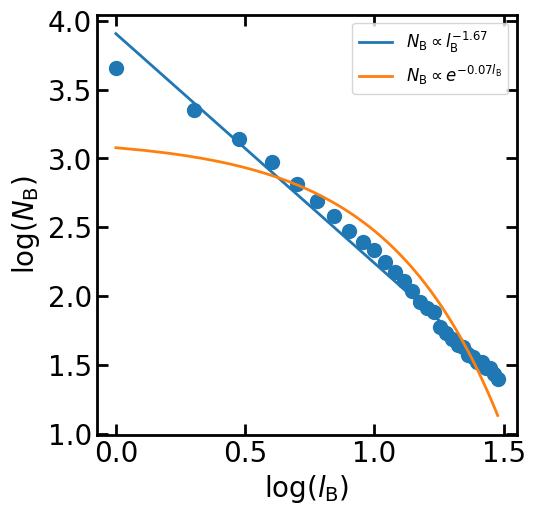

In [43]:
calculate_n_plot_power_law(json_test['radius'], json_test['size'], f"{analysis_folder}human_brains__BNU1_0025915_2_DTI_DS16784")